In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
dataset_path = "/content/drive/MyDrive/Colab Notebooks/odi_parsed.csv"
df = pd.read_csv(dataset_path)

In [ ]:
df.head()

,match_id,inning,team,over,ball_in_over,delivery_index,extras,score_band,wickets_lost,is_legal,runs_batsman,is_wicket,batsman,non_striker,bowler,cumulative_runs
0,209582,1,Pakistan,0,1,0,0,0,0,True,0,0,Salman Butt,Shahid Afridi,IDR Bradshaw,0
1,209582,1,Pakistan,0,2,1,0,0,0,True,0,0,Salman Butt,Shahid Afridi,IDR Bradshaw,0
2,209582,1,Pakistan,0,3,2,0,0,0,True,0,0,Salman Butt,Shahid Afridi,IDR Bradshaw,0
3,209582,1,Pakistan,0,4,3,0,0,0,True,0,0,Salman Butt,Shahid Afridi,IDR Bradshaw,0
4,209582,1,Pakistan,0,5,4,0,0,0,True,0,0,Salman Butt,Shahid Afridi,IDR Bradshaw,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1550015 entries, 0 to 1550014
Data columns (total 16 columns):
 #   Column           Non-Null Count    Dtype 
---  ------           --------------    ----- 
 0   match_id         1550015 non-null  int64 
 1   inning           1550015 non-null  int64 
 2   team             1550015 non-null  object
 3   over             1550015 non-null  int64 
 4   ball_in_over     1550015 non-null  int64 
 5   delivery_index   1550015 non-null  int64 
 6   extras           1550015 non-null  int64 
 7   score_band       1550015 non-null  int64 
 8   wickets_lost     1550015 non-null  int64 
 9   is_legal         1550015 non-null  bool  
 10  runs_batsman     1550015 non-null  int64 
 11  is_wicket        1550015 non-null  int64 
 12  batsman          1550015 non-null  object
 13  non_striker      1550015 non-null  object
 14  bowler           1550015 non-null  object
 15  cumulative_runs  1550015 non-null  int64 
dtypes: bool(1), int64(11), object(4)
mem

In [ ]:
df["match_id"].nunique()

2928

In [ ]:
def prepare_features(df, include_dot_balls=True):
    """
    Improved version that maintains full trajectory length
    """
    # Validate required columns
    required_columns = ['match_id', 'inning', 'team', 'over', 'ball_in_over',
                      'wickets_lost', 'cumulative_runs', 'runs_batsman', 'extras']
    if not all(col in df.columns for col in required_columns):
        missing = [col for col in required_columns if col not in df.columns]
        raise ValueError(f"Missing columns: {missing}")

    # Get match outcomes (more robust version)
    match_results = (
        df.groupby(['match_id', 'inning', 'team'])
        .agg(final_runs=('cumulative_runs', 'last'),
             balls_played=('over', 'count'))
        .reset_index()
    )

    expert_features = []
    non_expert_features = []

    for match_id in df['match_id'].unique():
        match_data = match_results[match_results['match_id'] == match_id]

        # Skip incomplete matches
        if len(match_data) < 2:
            continue

        # Sort innings by inning number to ensure correct comparison
        match_data = match_data.sort_values('inning')

        # Determine winner (expert) - handles ties better
        if match_data.iloc[0]['final_runs'] > match_data.iloc[1]['final_runs']:
            expert_team, non_expert_team = match_data.iloc[0]['team'], match_data.iloc[1]['team']
        else:
            expert_team, non_expert_team = match_data.iloc[1]['team'], match_data.iloc[0]['team']

        # Process full trajectories
        expert_traj = process_full_trajectory(
            df[(df['match_id'] == match_id) & (df['team'] == expert_team)]
        )
        non_expert_traj = process_full_trajectory(
            df[(df['match_id'] == match_id) & (df['team'] == non_expert_team)]
        )

        if len(expert_traj) > 50:
            expert_features.append(expert_traj)
        if len(non_expert_traj) > 50:
            non_expert_features.append(non_expert_traj)

    return expert_features, non_expert_features

def process_full_trajectory(inning_df, include_dot_balls=True):
    """Processes complete innings without filtering valid actions"""
    features = []
    inning_df = inning_df.sort_values(['over', 'ball_in_over'])

    for _, row in inning_df.iterrows():
        state = [
            row['over'],
            row['wickets_lost'],
            row['cumulative_runs'],  # Using actual runs instead of band
            row['ball_in_over'],
        ]

        action = row['runs_batsman']

        # Include all actions or filter based on parameter
        if action in {0,1,2,3,4,6}:
            features.append((state, action))

    return features

In [ ]:
expert_features, non_expert_features = prepare_features(df)


In [ ]:
for i in range(1,5):
  print(len(non_expert_features[i]))


287
292
309
236


In [ ]:
import numpy as np
def calculate_feature_expectations(trajectories):
    """Calculate feature expectations for 4 state + 6 action features"""
    # 4 state features + 6 action features (0,1,2,3,4,6 runs)
    feat_exp = np.zeros(9)
    counts = np.zeros(9)

    for traj in trajectories:
        for state, action in traj:
            # State features - normalized
            feat_exp[:4] += [
                state[0]/50,   # over (0-50)
                state[1]/10,   # wickets (0-10)
                state[2]/400,  # cumulative runs
                state[3]/6    # ball in over (0-5)
            ]
            counts[:4] += 1

            if action in {1,2,3,4,6}:
                action_idx = 4 + { 1:0, 2:1, 3:2, 4:3, 6:4}[action]
                feat_exp[action_idx] += 1
                counts[action_idx] += 1

    counts = np.maximum(counts, 1)
    return feat_exp / counts

In [ ]:
def inverse_reinforcement_learning(expert_features, non_expert_features, max_iterations=100, epsilon=0.05):
    """Stable IRL implementation matching paper's LP approach"""
    # Compute normalized feature expectations
    expert_mu = calculate_feature_expectations(expert_features)
    print("Normalized expert feature expectations:")
    print(f"State: {expert_mu[:5]}")
    print(f"Actions: {expert_mu[5:]}")

    # Initialize coefficients with cricket knowledge
    coefficients = np.array([
        0.8,    # x1: Over
        -0.3,   # x2: Wickets
        0.7,    # x3: Score
        0.4,    # x4: Ball in over
        0.3,    # y1: 1 run
        0.8,    # y2: 2 runs
        0.1,    # y3: 3 runs
        0.6,    # y4: 4 runs
        0.4     # y6: 6 runs
    ])

    conditions_pool = []
    remaining_trajectories = non_expert_features.copy()

    for iteration in range(max_iterations):
        if not remaining_trajectories:
            break

        # Get next non-expert trajectory
        non_expert_mu = calculate_feature_expectations([remaining_trajectories.pop(0)])

        # Check margin
        diff = expert_mu - non_expert_mu
        current_margin = np.dot(coefficients, diff)
        if current_margin >= epsilon:
            continue

        # Add new condition
        conditions_pool.append(diff)

        # Solve LP with regularization
        A = -np.array(conditions_pool)  # Convert to <=
        b = -np.ones(len(conditions_pool)) * epsilon

        # Natural bounds:
        bounds = [
            (0, None),    # x1
            (None, 0),    # x2 (negative)
            (0, None),    # x3
            (0, None),    # x4
            (0, None),    # y1
            (0, None),    # y2
            (0, None),    # y3
            (0, None),    # y4
            (0, None)     # y6
        ]

        # Add small L2 regularization to prevent extreme values
        # This is implemented by adding dummy variables
        n_vars = len(coefficients)
        c = np.zeros(n_vars * 2)
        c[:n_vars] = 1  # Original coefficients
        c[n_vars:] = 0.1  # Regularization terms

        # Expand A matrix for dummy variables
        A_expanded = np.hstack([A, np.zeros((A.shape[0], n_vars))])

        # Minimize:     cᵀx
        # Subject to:   A_ub @ x ≤ b_ub
        #               A_eq @ x == b_eq
        #               lb ≤ x ≤ ub
        result = linprog(
            c=c,
            A_ub=A_expanded,
            b_ub=b,
            bounds=bounds * 2,
            method='highs'
        )

        if result.success:
            new_coefficients = result.x[:n_vars]

            # Print progress
            print(f"\nIteration {iteration}:")
            print(f"Margins: {[-row @ new_coefficients for row in A]}")
            print(f"New coeffs: {new_coefficients}")

            coefficients = new_coefficients

    state_norm = np.linalg.norm(coefficients[:4])
    if state_norm > 0:
        coefficients = coefficients / state_norm

    return coefficients

In [ ]:
from scipy.optimize import linprog
print("\nPreparing features...")
expert_features, non_expert_features = prepare_features(df)

if not expert_features or not non_expert_features:
  print("Error: Not enough valid matches found")
else:
    print(f"\nFound {len(expert_features)} expert and {len(non_expert_features)} non-expert trajectories")


    # Run IRL
    print("\nRunning IRL...")
    coefficients = inverse_reinforcement_learning(expert_features, non_expert_features)

    # Print results
    print("\n\n=== Learned Reward Function ===")
    print("State coefficients:")
    print(f"  Over progression (x1): {coefficients[0]:.4f}")
    print(f"  Wickets lost (x2): {coefficients[1]:.4f}")
    print(f"  Score band (x3): {coefficients[2]:.4f}")
    print(f"  ball in over (x4): {coefficients[3]:.4f}")

    print("\nAction coefficients (weighted by 1000):")
    print(f"  1 run (y1): {coefficients[4]:.4f}")
    print(f"  2 runs (y2): {coefficients[5]:.4f}")
    print(f"  3 runs (y3): {coefficients[6]:.4f}")
    print(f"  4 runs (y4): {coefficients[7]:.4f}")
    print(f"  6 runs (y6): {coefficients[8]:.4f}")


Preparing features...

Found 2846 expert and 2833 non-expert trajectories

Running IRL...
Normalized expert feature expectations:
State: [0.44966266 0.229048   0.28939311 0.59934192 1.        ]
Actions: [1. 1. 1. 1.]


=== Learned Reward Function ===
State coefficients:
  Over progression (x1): 0.6810
  Wickets lost (x2): -0.2554
  Score band (x3): 0.5959
  ball in over (x4): 0.3405

Action coefficients (weighted by 1000):
  1 run (y1): 0.2554
  2 runs (y2): 0.6810
  3 runs (y3): 0.0851
  4 runs (y4): 0.5108
  6 runs (y6): 0.3405


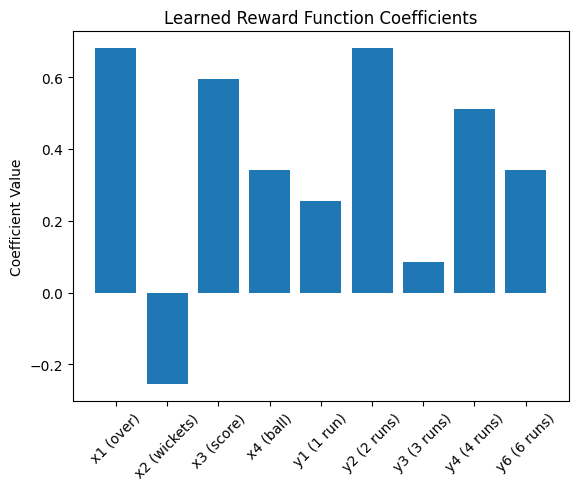

In [ ]:
import matplotlib.pyplot as plt
def plot_coefficients(coefficients):
    labels = ['x1 (over)', 'x2 (wickets)', 'x3 (score)', 'x4 (ball)',
             'y1 (1 run)', 'y2 (2 runs)', 'y3 (3 runs)', 'y4 (4 runs)', 'y6 (6 runs)']
    plt.bar(labels, coefficients)
    plt.xticks(rotation=45)
    plt.ylabel('Coefficient Value')
    plt.title('Learned Reward Function Coefficients')
    plt.show()
plot_coefficients(coefficients)

In [ ]:
import pandas as pd
from collections import defaultdict

def calculate_transition_and_wicket_probs(df):
    """
     Resets cumulative runs and wickets when new match starts
    """

    df_first = df[df['inning'] == 1].sort_values(['match_id', 'over', 'ball_in_over'])

    run_counts = defaultdict(lambda: defaultdict(int))
    wicket_counts = defaultdict(int)
    ball_counts = defaultdict(int)

    cumulative_runs = 0
    cumulative_wickets = 0
    last_match_id = None

    for _, row in df_first.iterrows():
        match_id = row['match_id']

        # Reset when new match starts
        if match_id != last_match_id:
            cumulative_runs = 0
            cumulative_wickets = 0
            last_match_id = match_id

        over = row['over']
        ball_in_over = row['ball_in_over']
        runs_batsman = row['runs_batsman']
        runs_extras = row['extras']
        is_wicket = row['is_wicket']
        extras_flag = 1 if runs_extras > 0 else 0
        pre_score_band = cumulative_runs // 10
        state = (over, cumulative_wickets, pre_score_band, ball_in_over, extras_flag)


        ball_counts[state] += 1

        if is_wicket:
            wicket_counts[state] += 1
            cumulative_wickets += 1
        else:
            total_runs = runs_batsman + runs_extras
            run_counts[state][total_runs] += 1
            cumulative_runs += total_runs

    transition_probs = defaultdict(dict)
    wicket_probs = {}

    for state in ball_counts:
        total_balls = ball_counts[state]
        wickets = wicket_counts[state]

        wicket_probs[state] = wickets / total_balls

        if total_balls - wickets > 0:
            for runs in run_counts[state]:
                trans_prob = run_counts[state][runs] / (total_balls - wickets)
                transition_probs[state][runs] = trans_prob

    return dict(transition_probs), wicket_probs

In [ ]:
trans_probs,wicket_probs=calculate_transition_and_wicket_probs(df)

In [ ]:
trans_probs

In [ ]:
wicket_probs

In [ ]:
import numpy as np

def build_optimal_policy(transition_probs, wicket_probs, reward_coefficients):
    """
    Build an optimal policy mapping from states to best action.
    Uses the learned reward function from IRL.
    """

    possible_actions = [0, 1, 2, 3, 4, 6]
    optimal_policy = {}

    for state in transition_probs.keys():
        best_action = None
        best_value = -np.inf

        for action in possible_actions:
            feature_vec = np.zeros(10)

            # State features normalized
            feature_vec[0] = state[0] / 50     # over
            feature_vec[1] = state[1] / 10     # wickets lost
            feature_vec[2] = state[2] / 40     # score band
            feature_vec[3] = state[3] / 6      # ball in over
            feature_vec[4] = state[4]           # extras

            # Action features (one-hot encoding)
            if action in {1,2,3,4,6}:
                action_idx = {1:0, 2:1, 3:2, 4:3, 6:4}[action]
                feature_vec[5 + action_idx] = 1

            # Calculate reward
            reward = np.dot(reward_coefficients, feature_vec)

            # Calculate expected reward after action
            # (Here, reward is simplified because we only consider immediate reward, no full future discounting)

            if reward > best_value:
                best_value = reward
                best_action = action

        optimal_policy[state] = best_action

    return optimal_policy


In [ ]:
optimal_policy = build_optimal_policy(trans_probs, wicket_probs, coefficients_rescaled)


In [ ]:
optimal_policy

In [ ]:
import random

def choose_action_with_randomness(optimal_action, possible_actions, epsilon=0.1):
    if random.random() < epsilon:
        return random.choice(possible_actions)
    else:
        return optimal_action

def simulate_full_innings(optimal_policy, transition_probs, wicket_probs, epsilon=0.1):
    """
    Simulate a full innings using epsilon-greedy policy.
    """
    possible_actions = [0, 1, 2, 3, 4, 6]
    total_runs = 0

    # Start state
    state = [0, 0, 0, 0, 0]  # over, wickets, score_band, ball_in_over, extras_flag
    ball_number = 0

    while state[0] < 50 and state[1] < 10:
        state_key = tuple(state)

        # Get optimal action
        optimal_action = optimal_policy.get(state_key, 0)

        # Apply epsilon-greedy
        action = choose_action_with_randomness(optimal_action, possible_actions, epsilon)

        # Check if wicket falls
        wicket_chance = wicket_probs.get(state_key, 0.05)  # fallback wicket prob
        if random.random() < wicket_chance:
            state[1] += 1  # wicket
            state[3] += 1  # ball advanced
        else:

            total_runs += action
            current_score = state[2]*10 + action
            state[2] = min(current_score // 10, 49)
            state[3] += 1
        if state[3] >= 6:
            state[3] = 0
            state[0] += 1

        ball_number += 1
        print(state,'-->',total_runs,"action is ",action)
    return total_runs


In [ ]:
final_score = simulate_full_innings(policy, trans_probs, wicket_probs, epsilon=0.1)

print(f"Simulated Final Score: {final_score} runs")

In [ ]:
import random

# Define safe defaults
DEFAULT_TRANSITION_PROB = {0: 1.0}  # Assume 0 runs if unknown
DEFAULT_WICKET_PROB = 0.05          # 5% wicket chance if unknown

def simulate_innings_with_policy(start_state, transition_probs, wicket_probs, optimal_policy, interruption_ball=None):
    """
    Simulate one innings using an optimal policy, handling missing states with safe fallbacks.

    Parameters:
    - start_state: initial state (over, wickets, score_band, ball_in_over, extras_flag)
    - transition_probs: learned transition probabilities
    - wicket_probs: learned wicket probabilities
    - optimal_policy: dict mapping state -> best action
    - interruption_ball: optional, stop simulation after this many balls
    """

    state = list(start_state)
    total_runs = 0
    ball_number = 0  # ball counter

    while state[0] < 50 and state[1] < 10:
        if interruption_ball is not None and ball_number == interruption_ball:
            break

        state_key = tuple(state)

        # Get wicket chance (with fallback)
        wicket_chance = wicket_probs.get(state_key, DEFAULT_WICKET_PROB)

        # Wicket happens?
        if random.random() < wicket_chance:
            state[1] += 1  # Wicket lost
            state[3] += 1  # Ball advances
        else:
            # Choose action using optimal policy
            action = optimal_policy.get(state_key, 0)  # fallback safe action = 0 runs if policy missing

            # Apply action
            total_runs += action
            current_score = state[2]*10 + action
            state[2] = min(current_score // 10, 49)  # Update score band
            state[3] += 1  # Advance ball

        # Over completed?
        if state[3] >= 6:
            state[3] = 0
            state[0] += 1

        ball_number += 1

    return total_runs

In [ ]:
def get_optimal_action_with_dynamic_risk(state, coefficients, wicket_penalty=-10):
    possible_actions = [1, 2, 3, 4, 6]

    base_wicket_loss_prob = {
        1: 0.01,
        2: 0.02,
        3: 0.04,
        4: 0.07,
        6: 0.15
    }

    over = state[0]
    wickets_lost = state[1]
    wickets_left = 10 - wickets_lost
    overs_left = 50 - over

    # Heuristic: Adjust riskiness dynamically
    adjusted_loss_prob = base_wicket_loss_prob.copy()

    if wickets_left <= 3:
        # Very few wickets left → increase risk perception
        for action in adjusted_loss_prob:
            adjusted_loss_prob[action] *= 2.5  # Increase risk heavily
    elif overs_left <= 10 and wickets_left >= 6:
        # End overs and many wickets left → take more risks
        for action in adjusted_loss_prob:
            adjusted_loss_prob[action] *= 0.5  # Reduce perceived risk
    elif 10 < over <= 35:
        # Middle overs → balanced risk
        for action in adjusted_loss_prob:
            adjusted_loss_prob[action] *= 1.2  # Slightly cautious

    best_action = None
    best_expected_reward = -np.inf

    for action in possible_actions:
        feature_vec = np.zeros(10)

        feature_vec[0] = state[0] / 50
        feature_vec[1] = state[1] / 10
        feature_vec[2] = state[2] / 50
        feature_vec[3] = state[3] / 6
        feature_vec[4] = state[4]

        action_idx = {1: 0, 2: 1, 3: 2, 4: 3, 6: 4}[action]
        feature_vec[5 + action_idx] = 1

        raw_reward = np.dot(coefficients, feature_vec)

        expected_reward = raw_reward + (adjusted_loss_prob[action] * wicket_penalty)

        if expected_reward > best_expected_reward:
            best_expected_reward = expected_reward
            best_action = action
        if state[0]>40:
          print(state,best_action)
    return best_action


In [ ]:
def build_optimal_policy(coefficients):
    """
    Precompute the best action for every possible state.
    """
    optimal_policy = {}

    for over in range(0, 51):
        for wickets in range(0, 11):
            for score_band in range(0, 50):
                for ball_in_over in range(0, 6):
                    for extras in [0, 1]:
                        state = [over, wickets, score_band, ball_in_over, extras]
                        action = get_optimal_action_with_risk(state, coefficients)
                        optimal_policy[tuple(state)] = action
    return optimal_policy

In [ ]:
print("\nBuilding optimal policy...")
optimal_policy = build_optimal_policy(coefficients_rescaled)
print(f"Optimal policy computed for {len(optimal_policy)} states.")
